Linear Regression MSE: 898837301.5299124
Linear Regression R2: -0.24562798758116955
Random Forest MSE: 782022203.1097773
Random Forest R2: -0.08374312174783194


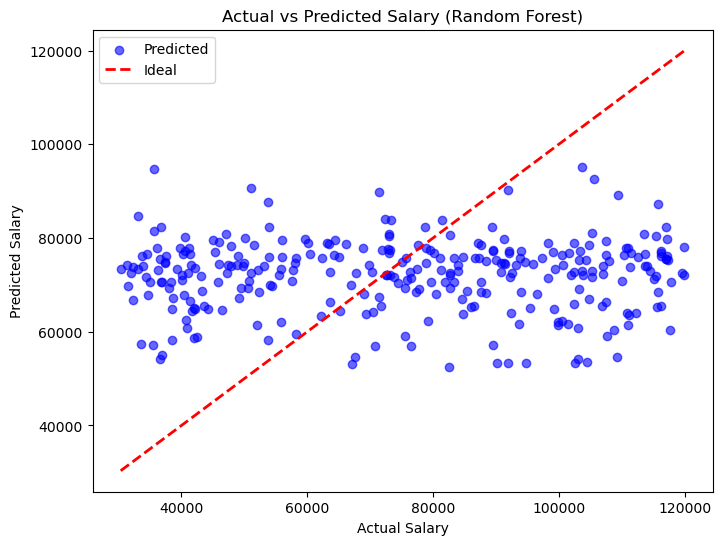

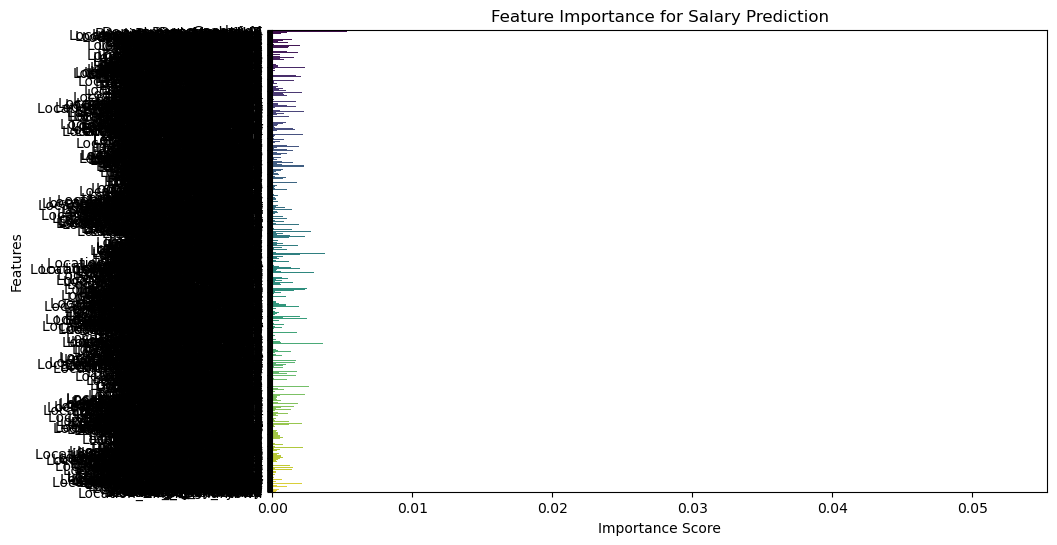

In [3]:
import pandas as pd
import random
from faker import Faker
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# -----------------------------
# Step 1: Generate synthetic dataset
# -----------------------------
fake = Faker()
departments = {
    "HR": ["HR Executive", "Recruiter", "HR Manager"],
    "Finance": ["Accountant", "Finance Analyst", "Finance Manager"],
    "IT": ["Software Engineer", "QA Engineer", "System Administrator"],
    "Marketing": ["Marketing Analyst", "Marketing Manager", "Content Strategist"],
    "Sales": ["Sales Executive", "Sales Manager", "Business Development"],
    "Operations": ["Operations Executive", "Operations Lead", "Logistics Manager"]
}

employees = []
for emp_id in range(1, 1501):
    dept = random.choice(list(departments.keys()))
    job = random.choice(departments[dept])
    employees.append({
        "EmployeeID": f"{emp_id:04d}",
        "Name": fake.name(),
        "Age": random.randint(22, 60),
        "Gender": random.choice(["M", "F"]),
        "Department": dept,
        "Job Title": job,
        "Date of Joining": fake.date_between(start_date="-10y", end_date="today"),
        "Salary": random.randint(30000, 120000),
        "Location": fake.city()
    })

df = pd.DataFrame(employees)

# -----------------------------
# Step 2: Preprocess
# -----------------------------
X = df[["Age", "Gender", "Department", "Location"]]
y = df["Salary"]

X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# Step 3: Train Models
# -----------------------------
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# -----------------------------
# Step 4: Evaluate
# -----------------------------
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

print("Random Forest MSE:", mean_squared_error(y_test, y_pred_rf))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

# Visualization
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color="blue", label="Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Ideal")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary (Random Forest)")
plt.legend()
plt.show()

# -----------------------------
# Step 5: Feature Importance
# -----------------------------
importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features, palette="viridis")
plt.title("Feature Importance for Salary Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


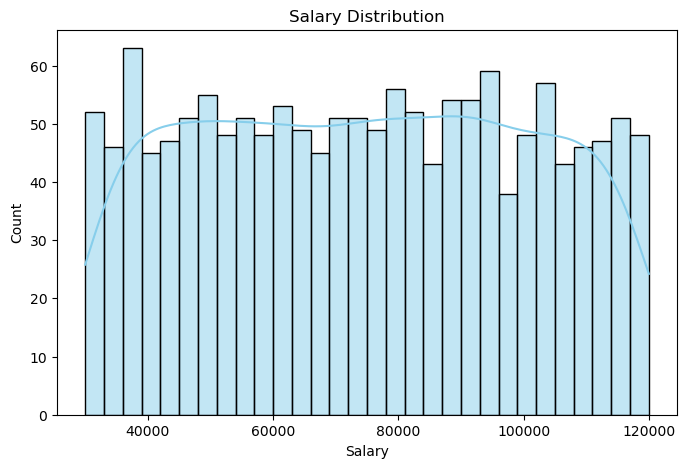

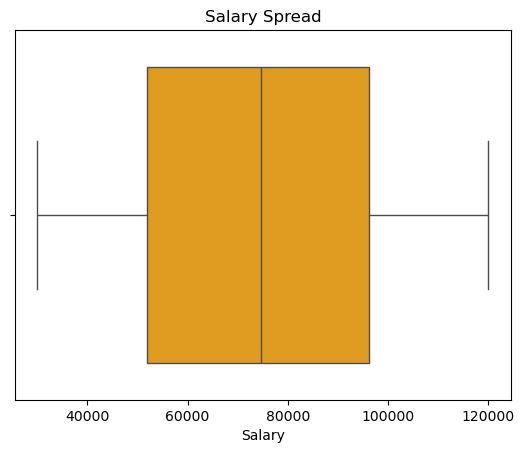

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df["Salary"], bins=30, kde=True, color="skyblue")
plt.title("Salary Distribution")
plt.show()

sns.boxplot(x=df["Salary"], color="orange")
plt.title("Salary Spread")
plt.show()


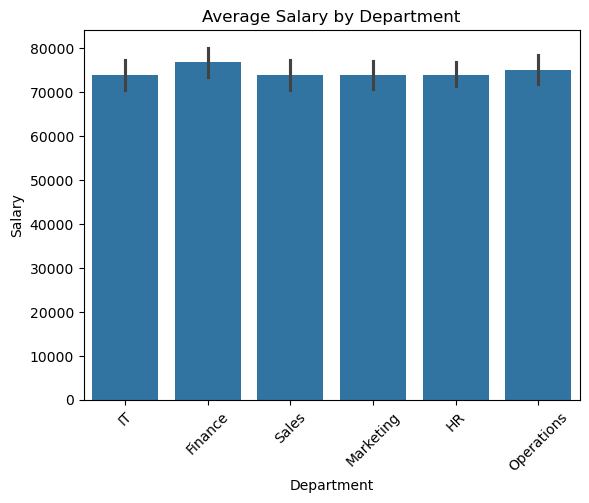

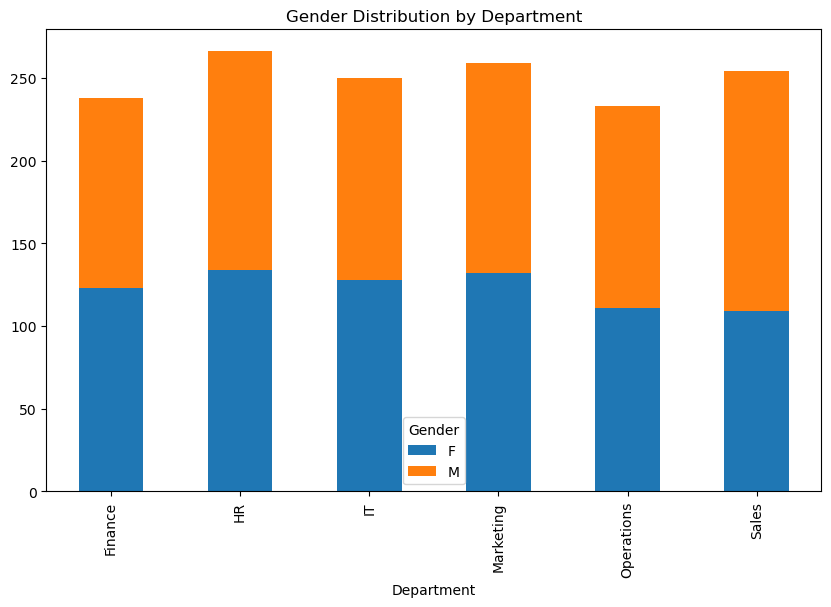

In [5]:
sns.barplot(x="Department", y="Salary", data=df, estimator=lambda x: sum(x)/len(x))
plt.title("Average Salary by Department")
plt.xticks(rotation=45)
plt.show()

pd.crosstab(df["Department"], df["Gender"]).plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Gender Distribution by Department")
plt.show()


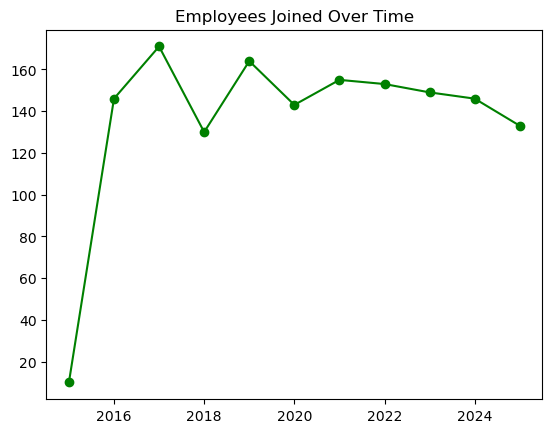

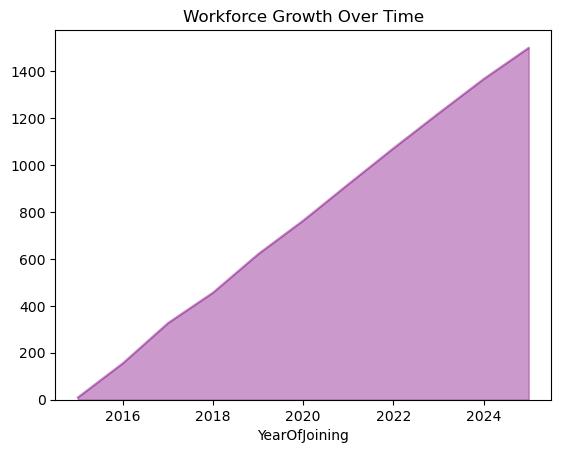

In [6]:
df["YearOfJoining"] = pd.to_datetime(df["Date of Joining"]).dt.year
join_counts = df["YearOfJoining"].value_counts().sort_index()

plt.plot(join_counts.index, join_counts.values, marker="o", color="green")
plt.title("Employees Joined Over Time")
plt.show()

df.groupby("YearOfJoining").size().cumsum().plot(kind="area", alpha=0.4, color="purple")
plt.title("Workforce Growth Over Time")
plt.show()


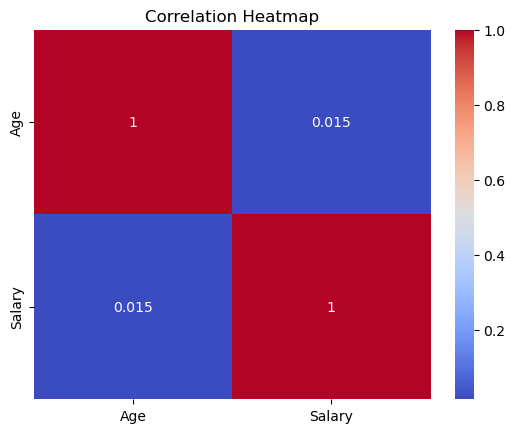

In [7]:
sns.heatmap(df[["Age","Salary"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


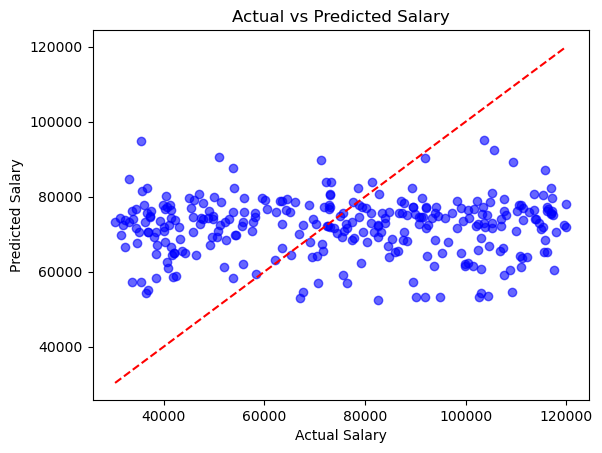

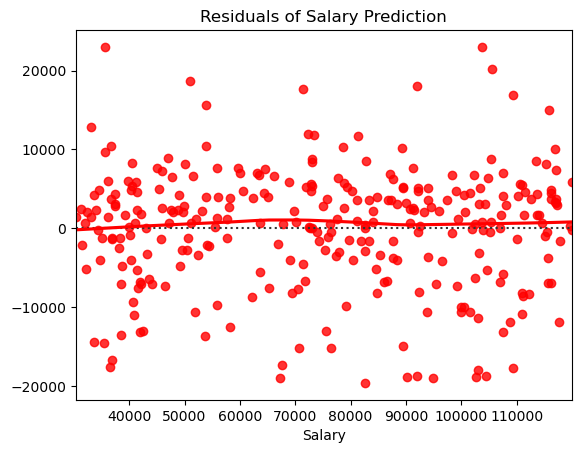

In [8]:
plt.scatter(y_test, y_pred_rf, alpha=0.6, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

sns.residplot(x=y_test, y=y_pred_rf, lowess=True, color="red")
plt.title("Residuals of Salary Prediction")
plt.show()
